In [ ]:
from pathlib import Path
from paquo.projects import QuPathProject
import subprocess

# === CONFIG ===
# Path to QuPath executable (update this to your install)
# QUPATH_EXE = r"C:\Program Files\QuPath-0.5.0\QuPath-0.5.0.exe"
QUPath_EXE = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"

# QuPath project you want to create/use
PROJECT_PATH = r"C:\Users\Vivian\Documents\qupath_ann_testing\fa_pt_cells.qpproj"
# GROOVY_SCRIPT = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\cell_detection.groovy"

# Directory containing your WSIs (e.g., .vsi)
WSI_DIR = r"Z:\mirage\med-i_data\Data\Amoon\Pathology Raw"

# Groovy script that will do tiling + cell detection
GROOVY_SCRIPT = r"C:\Users\Vivian\Documents\qupath_ann_testing\tile_and_detect_cells.groovy"

# Extensions to include as WSIs
WSI_EXTS = (".vsi", ".svs", ".ndpi", ".tif", ".tiff", ".tiff2")  # adjust as needed


def create_or_update_project():
    """
    Create a QuPath project (or overwrite if already exists, because mode='w')
    and add all WSIs from WSI_DIR.
    """
    wsi_dir = Path(WSI_DIR)

    with QuPathProject(PROJECT_PATH, mode="w") as project:
        # Add all WSIs
        for p in sorted(wsi_dir.rglob("*")):
            if p.suffix.lower() in WSI_EXTS:
                print(f"Adding WSI to project: {p}")
                project.add_image(str(p))

    print(f"Project saved at: {PROJECT_PATH}")


def run_groovy_script_headless():
    """
    Call QuPath in headless mode to run the Groovy script
    over the project created above.
    """
    cmd = [
        QUPATH_EXE,
        "script",           # QuPath CLI subcommand
        PROJECT_PATH,       # project to operate on
        GROOVY_SCRIPT       # script to run
    ]
    print("Running QuPath headless with command:")
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)
    print("QuPath script finished.")


if __name__ == "__main__":
    create_or_update_project()
    run_groovy_script_headless()


run on one slide

In [5]:
from paquo.projects import QuPathProject

PROJECT = r"C:\Users\Vivian\Documents\qupath_projects\test_one_slide.qpproj"
WSI = r"Z:\med-i_data\Data\Amoon\Pathology Raw\FA scans\FA 57B.vsi"

with QuPathProject(PROJECT, mode="w") as proj:
    proj.add_image(WSI)

print("Project created:", PROJECT)


backing up qupath_projects before truncating! (this can be disabled via PAQUO_SAFE_TRUNCATE)


Project created: C:\Users\Vivian\Documents\qupath_projects\test_one_slide.qpproj


In [6]:
from paquo.projects import QuPathProject
import subprocess
from pathlib import Path

# QUPATH = r"C:\Program Files\QuPath-0.5.0\QuPath-0.5.0.exe"
QUPATH = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
PROJECT = r"C:\Users\Vivian\Documents\qupath_projects\project.qpproj"
# GROOVY = r"C:\Users\Vivian\Documents\qupath_scripts\tile_and_detect_cells_per_slide.groovy"
GROOVY = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\tile_and_detect_cells.groovy"

WSI = r"Z:\med-i_data\Data\Amoon\Pathology Raw\FA scans\FA 57B.vsi"   # <<— ONLY ONE SLIDE

# Create project with 1 slide
with QuPathProject(PROJECT, mode="w") as proj:
    proj.add_image(WSI)

# Run Groovy script on that one slide
cmd = [QUPATH, "script", PROJECT, GROOVY]
subprocess.run(cmd, check=True)

print("Done. Check cell_measurements/ folder inside the project.")


backing up qupath_projects before truncating! (this can be disabled via PAQUO_SAFE_TRUNCATE)


Done. Check cell_measurements/ folder inside the project.


In [2]:
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
print("Created PROJECT_ROOT, exists now?", PROJECT_ROOT.exists())


Created PROJECT_ROOT, exists now? True


In [3]:
from paquo.projects import QuPathProject

WSI = r"Z:\med-i_data\Data\Amoon\Pathology Raw\FA scans\FA 57B.vsi"

with QuPathProject(str(PROJECT), mode="w") as proj:
    print("Inside context: project dir exists?", PROJECT.exists())
    proj.add_image(WSI)

print("After context: project dir exists?", PROJECT.exists())
print("Is dir?                         ", PROJECT.is_dir())


backing up qupath_projects before truncating! (this can be disabled via PAQUO_SAFE_TRUNCATE)


Inside context: project dir exists? False
After context: project dir exists? False
Is dir?                          False


In [1]:
from pathlib import Path
from paquo.projects import QuPathProject

# --- CONFIG ---
PROJECT_ROOT = Path(r"C:\Users\Vivian\Documents\qupath_projects")
PROJECT = PROJECT_ROOT / "FA_57B_cells_project.qpproj"   # <- NOTE: nested folder with .qpproj
WSI = Path(r"Z:\med-i_data\Data\Amoon\Pathology Raw\FA scans\FA 57B.vsi")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROJECT     :", PROJECT)
print("PROJECT basename:", PROJECT.name)
print("Parent exists before?", PROJECT.parent.exists())

# Ensure parent directory exists
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
print("Parent exists after mkdir?", PROJECT.parent.exists())

print("\n>>> Creating project with QuPathProject(PROJECT, mode='w')")

with QuPathProject(str(PROJECT), mode="w") as proj:
    print("Inside context: PROJECT exists?", PROJECT.exists())
    print("Inside context: PROJECT is dir?", PROJECT.is_dir())
    proj.add_image(str(WSI))

print("After context: PROJECT exists?", PROJECT.exists())
print("After context: PROJECT is dir?", PROJECT.is_dir())


backing up qupath_projects before truncating! (this can be disabled via PAQUO_SAFE_TRUNCATE)


PROJECT_ROOT: C:\Users\Vivian\Documents\qupath_projects
PROJECT     : C:\Users\Vivian\Documents\qupath_projects\FA_57B_cells_project.qpproj
PROJECT basename: FA_57B_cells_project.qpproj
Parent exists before? True
Parent exists after mkdir? True

>>> Creating project with QuPathProject(PROJECT, mode='w')
Inside context: PROJECT exists? False
Inside context: PROJECT is dir? False
After context: PROJECT exists? False
After context: PROJECT is dir? False


In [2]:
from pathlib import Path
from paquo.projects import QuPathProject

PROJECT = r"C:\Users\Vivian\Documents\qupath_projects"  # <-- this *is* the QuPath project
WSI = r"Z:\med-i_data\Data\Amoon\Pathology Raw\FA scans\FA 57B.vsi"

print("PROJECT path:", PROJECT)
print("Exists? ", Path(PROJECT).exists())
print("Is dir? ", Path(PROJECT).is_dir())

# IMPORTANT: use 'a' (append), NOT 'w'
with QuPathProject(PROJECT, mode="a") as proj:
    print("Opened existing project.")
    proj.add_image(WSI)  # will add FA 57B into this project

print("Done adding image.")


PROJECT path: C:\Users\Vivian\Documents\qupath_projects
Exists?  True
Is dir?  True
Opened existing project.
Done adding image.


In [3]:
import subprocess

QUPATH = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
GROOVY = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\tile_and_detect_cells.groovy"

cmd = [QUPATH, "script", GROOVY, "--project", PROJECT]
print("Running:", cmd)
subprocess.run(cmd, check=True)

print("Done. Now check cell_measurements inside the project folder.")


Running: ['C:\\Users\\Vivian\\paquo_qupath\\QuPath-0.5.1\\QuPath-0.5.1 (console).exe', 'script', 'C:\\Users\\Vivian\\Documents\\qupath_ann_testing\\scripts\\tile_and_detect_cells.groovy', '--project', 'C:\\Users\\Vivian\\Documents\\qupath_projects']


CalledProcessError: Command '['C:\\Users\\Vivian\\paquo_qupath\\QuPath-0.5.1\\QuPath-0.5.1 (console).exe', 'script', 'C:\\Users\\Vivian\\Documents\\qupath_ann_testing\\scripts\\tile_and_detect_cells.groovy', '--project', 'C:\\Users\\Vivian\\Documents\\qupath_projects']' returned non-zero exit status 1.

In [ ]:
import subprocess

QUPATH = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
GROOVY = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\tile_and_detect_cells.groovy"

PROJECT_FILE = r"C:\Users\Vivian\Documents\qupath_projects\project.qpproj"

cmd = [QUPATH, "script", GROOVY, "--project", PROJECT_FILE]
print("Running:", cmd)

# result = subprocess.run(cmd, capture_output=True, text=True)
# No capture_output, no decoding → no Unicode issues
subprocess.run(cmd, check=True)
print("Done. Check cell_measurements in the project folder.")

# print("Return code:", result.returncode)
# print("=== STDOUT ===")
# print(result.stdout)
# print("=== STDERR ===")
# print(result.stderr)


Running: ['C:\\Users\\Vivian\\paquo_qupath\\QuPath-0.5.1\\QuPath-0.5.1 (console).exe', 'script', 'C:\\Users\\Vivian\\Documents\\qupath_ann_testing\\scripts\\tile_and_detect_cells.groovy', '--project', 'C:\\Users\\Vivian\\Documents\\qupath_projects\\project.qpproj']


Exception in thread Thread-3:
Traceback (most recent call last):
  File "c:\Users\Vivian\anaconda3\envs\panther\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "c:\Users\Vivian\anaconda3\envs\panther\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\Vivian\anaconda3\envs\panther\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Vivian\anaconda3\envs\panther\lib\subprocess.py", line 1495, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\Vivian\anaconda3\envs\panther\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb5 in position 853: invalid start byte


Return code: 0
=== STDOUT ===
None
=== STDERR ===



Columns in TSV:
['Image', 'Object ID', 'Object type', 'Name', 'Classification', 'Parent', 'ROI', 'Centroid X µm', 'Centroid Y µm', 'Nucleus: Area', 'Nucleus: Perimeter', 'Nucleus: Circularity', 'Nucleus: Max caliper', 'Nucleus: Min caliper', 'Nucleus: Eccentricity', 'Nucleus: Hematoxylin OD mean', 'Nucleus: Hematoxylin OD sum', 'Nucleus: Hematoxylin OD std dev', 'Nucleus: Hematoxylin OD max', 'Nucleus: Hematoxylin OD min', 'Nucleus: Hematoxylin OD range', 'Nucleus: Eosin OD mean', 'Nucleus: Eosin OD sum', 'Nucleus: Eosin OD std dev', 'Nucleus: Eosin OD max', 'Nucleus: Eosin OD min', 'Nucleus: Eosin OD range', 'Cell: Area', 'Cell: Perimeter', 'Cell: Circularity', 'Cell: Max caliper', 'Cell: Min caliper', 'Cell: Eccentricity', 'Cell: Hematoxylin OD mean', 'Cell: Hematoxylin OD std dev', 'Cell: Hematoxylin OD max', 'Cell: Hematoxylin OD min', 'Cell: Eosin OD mean', 'Cell: Eosin OD std dev', 'Cell: Eosin OD max', 'Cell: Eosin OD min', 'Cytoplasm: Hematoxylin OD mean', 'Cytoplasm: Hematoxyl

,Image,Object ID,Object type,Name,Classification,Parent,ROI,Centroid X µm,Centroid Y µm,Nucleus: Area,...,Cell: Eosin OD min,Cytoplasm: Hematoxylin OD mean,Cytoplasm: Hematoxylin OD std dev,Cytoplasm: Hematoxylin OD max,Cytoplasm: Hematoxylin OD min,Cytoplasm: Eosin OD mean,Cytoplasm: Eosin OD std dev,Cytoplasm: Eosin OD max,Cytoplasm: Eosin OD min,Nucleus/Cell area ratio
0,FA 57B.vsi - 20x,67c0e231-6748-454d-91dd-a82978e913a6,Cell,NaN,NaN,Annotation,Polygon,442.72,504.15,14.3344,...,0.0214,0.1050,0.0631,0.4082,-0.0036,0.2853,0.1606,0.8571,0.0214,0.0838
1,FA 57B.vsi - 20x,08dda8a3-c154-4aa4-a648-b90fcd950154,Cell,NaN,NaN,Annotation,Polygon,6343.30,422.28,22.6576,...,0.0214,0.0766,0.0680,0.3416,-0.0512,0.1691,0.1324,0.8104,0.0214,0.1024
2,FA 57B.vsi - 20x,5565e261-117b-46f6-a618-9f83b36a9b3e,Cell,NaN,NaN,Annotation,Polygon,6352.50,447.41,13.4096,...,0.0275,0.0018,0.0354,0.1408,-0.0644,0.2309,0.1011,0.5112,0.0275,0.0839
3,FA 57B.vsi - 20x,4a5cb005-547a-4b79-94fb-0f3c2055f395,Cell,NaN,NaN,Annotation,Polygon,6541.00,445.59,10.1728,...,0.0295,0.0909,0.0367,0.2252,0.0554,0.0703,0.0552,0.2642,0.0295,0.0963
4,FA 57B.vsi - 20x,3fe76c0f-a496-4e08-bd07-ec423a8871a8,Cell,NaN,NaN,Annotation,Polygon,6535.60,453.61,26.8192,...,0.0065,0.0996,0.0377,0.2444,0.0507,0.0846,0.0629,0.2827,0.0065,0.1613



Basic stats (selected numeric columns):


,Name,Classification,Centroid X µm,Centroid Y µm,Nucleus: Area,Nucleus: Perimeter,Nucleus: Circularity,Nucleus: Max caliper,Nucleus: Min caliper,Nucleus: Eccentricity,...,Cell: Eosin OD min,Cytoplasm: Hematoxylin OD mean,Cytoplasm: Hematoxylin OD std dev,Cytoplasm: Hematoxylin OD max,Cytoplasm: Hematoxylin OD min,Cytoplasm: Eosin OD mean,Cytoplasm: Eosin OD std dev,Cytoplasm: Eosin OD max,Cytoplasm: Eosin OD min,Nucleus/Cell area ratio
count,0.0,0.0,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,...,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06,1.103044e+06
mean,NaN,NaN,1.016680e+04,7.607457e+03,2.998117e+01,2.325951e+01,7.079064e-01,9.103675e+00,4.637660e+00,8.061605e-01,...,1.153013e-01,2.914609e-02,4.489907e-02,1.772614e-01,-5.547320e-02,2.593091e-01,6.725780e-02,4.512944e-01,1.167910e-01,2.172057e-01
std,NaN,NaN,4.768104e+03,3.186148e+03,1.615999e+01,8.102819e+00,1.654778e-01,3.454432e+00,1.453525e+00,1.446459e-01,...,6.510900e-02,6.244798e-02,1.548595e-02,9.152607e-02,6.342322e-02,8.010564e-02,3.131787e-02,1.652241e-01,6.460711e-02,9.187004e-02
min,NaN,NaN,1.753000e+01,7.172000e+00,6.473600e+00,1.054330e+01,7.580000e-02,3.531300e+00,1.602800e+00,0.000000e+00,...,-3.124400e+00,-1.377000e-01,8.100000e-03,-5.280000e-02,-6.172000e-01,2.400000e-03,7.500000e-03,6.660000e-02,-9.400000e-01,5.170000e-02
25%,NaN,NaN,6.285000e+03,5.205000e+03,1.895840e+01,1.757330e+01,5.889000e-01,6.686200e+00,3.615000e+00,7.302000e-01,...,6.720000e-02,-2.560000e-02,3.440000e-02,1.123000e-01,-1.078000e-01,2.042000e-01,4.620000e-02,3.467000e-01,6.860000e-02,1.479000e-01
50%,NaN,NaN,1.019355e+04,7.878100e+03,2.681920e+01,2.163425e+01,7.211000e-01,8.372600e+00,4.439500e+00,8.424000e-01,...,1.093000e-01,2.150000e-02,4.190000e-02,1.747000e-01,-7.220000e-02,2.487000e-01,6.000000e-02,4.212000e-01,1.109000e-01,1.986000e-01
75%,NaN,NaN,1.413850e+04,1.020340e+04,3.699200e+01,2.704190e+01,8.393000e-01,1.068900e+01,5.419300e+00,9.174000e-01,...,1.537000e-01,8.600000e-02,5.170000e-02,2.233000e-01,8.200000e-03,3.087000e-01,7.990000e-02,5.145000e-01,1.554000e-01,2.696000e-01
max,NaN,NaN,1.988790e+04,1.420160e+04,3.962768e+02,1.490976e+02,1.000000e+00,7.223390e+01,2.445160e+01,9.985000e-01,...,9.128000e-01,6.546000e-01,3.182000e-01,2.677000e+00,5.756000e-01,1.139100e+00,5.020000e-01,3.760000e+00,9.180000e-01,7.177000e-01



Top 5 patches by cell count:


patch_id
x8736_y11648    724
x2688_y8736     682
x1120_y9856     648
x7616_y11872    628
x4704_y6496     614
Name: count, dtype: int64


Target patch: x8736_y11648 at (patch_x=8736, patch_y=11648)
WSI scene size: (57959, 41401)
Patch image shape: (224, 224, 3)
Cells in target patch: 724


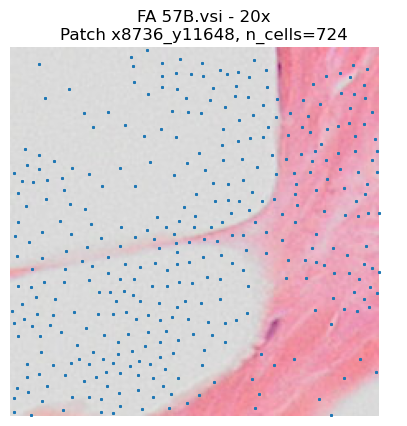

In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import slideio
from pathlib import Path

# -----------------------
# CONFIG
# -----------------------
project_dir = Path(r"C:\Users\Vivian\Documents\qupath_projects")
slide_display_name = "FA 57B.vsi - 20x"   # this is how QuPath named the 20x series
patch_size_px = 224                      # must match the PATCH_SIZE_PX you used in Groovy

# QuPath outputs
cells_tsv = project_dir / "cell_measurements" / f"{slide_display_name}_cells.tsv"
geojson_path = project_dir / "cell_measurements" / f"{slide_display_name}_nuclei.geojson"

# Path to original WSI
wsi_path = Path(r"Z:\med-i_data\Data\Amoon\Pathology Raw\FA scans\FA 57B.vsi")

# SlideIO scene index for the 20x image
# You may need to try 0 or 1 depending on how SlideIO sees the VSI scenes.
scene_index = 0   # try 0 if 1 fails / shows overview


# -----------------------
# 1. Load and inspect measurements
# -----------------------
df = pd.read_csv(cells_tsv, sep="\t")

print("Columns in TSV:")
print(df.columns.tolist())
print("\nHead:")
display(df.head())

print("\nBasic stats (selected numeric columns):")
display(df.select_dtypes(include=[np.number]).describe())


# -----------------------
# 2. Find centroid columns & compute virtual patch indices
# -----------------------
# QuPath column names vary slightly; search for Centroid X/Y
x_col = [c for c in df.columns if "Centroid X" in c][0]
y_col = [c for c in df.columns if "Centroid Y" in c][0]

df["cx"] = df[x_col]
df["cy"] = df[y_col]

df["tile_i"] = (df["cx"] // patch_size_px).astype(int)
df["tile_j"] = (df["cy"] // patch_size_px).astype(int)
df["patch_x"] = df["tile_i"] * patch_size_px
df["patch_y"] = df["tile_j"] * patch_size_px
df["patch_id"] = "x" + df["patch_x"].astype(int).astype(str) + "_y" + df["patch_y"].astype(int).astype(str)

print("\nTop 5 patches by cell count:")
patch_counts = df["patch_id"].value_counts()
display(patch_counts.head())

# Pick the densest patch to visualize
target_patch = patch_counts.index[0]
px, py = df.loc[df["patch_id"] == target_patch, ["patch_x", "patch_y"]].iloc[0]
print(f"\nTarget patch: {target_patch} at (patch_x={px}, patch_y={py})")


# -----------------------
# 3. Load WSI via SlideIO and read that patch region
# -----------------------
slide = slideio.open_slide(str(wsi_path), "VSI")  # driver=None lets SlideIO auto-detect
scene = slide.get_scene(scene_index)

# ROI rect is (x, y, width, height) in full-resolution pixels
roi = (int(px), int(py), int(patch_size_px), int(patch_size_px))
img = scene.read_block(rect=roi)  # returns H×W×C numpy array

print(f"WSI scene size: {scene.size}")
print(f"Patch image shape: {img.shape}")


# -----------------------
# 4. Filter cells belonging to this patch
# -----------------------
patch_cells = df[(df["patch_x"] == px) & (df["patch_y"] == py)].copy()
print(f"Cells in target patch: {len(patch_cells)}")


# -----------------------
# 5. (Optional) Load polygons for this patch from GeoJSON
# -----------------------
patch_polys = []
if geojson_path.exists():
    with open(geojson_path, "r") as f:
        gj = json.load(f)

    for feat in gj["features"]:
        props = feat.get("properties", {})
        # We stored patch_id, patch_x, patch_y in properties in the Groovy script
        if props.get("patch_x") == int(px) and props.get("patch_y") == int(py):
            coords = feat["geometry"]["coordinates"][0]  # outer ring
            patch_polys.append(np.array(coords))


# -----------------------
# 6. Visualize: WSI patch + centroids + (optionally) polygons
# -----------------------
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)

# Plot nuclei centroids (offset by patch origin)
ax.scatter(
    patch_cells["cx"] - px,
    patch_cells["cy"] - py,
    s=5,
    marker="o",
    linewidths=0.0,
)

# Overlay polygon outlines (if any from GeoJSON)
for poly in patch_polys:
    # poly is in full-slide coords → shift by patch origin
    xs = poly[:, 0] - px
    ys = poly[:, 1] - py
    ax.plot(xs, ys, linewidth=0.5)

ax.set_title(f"{slide_display_name}\nPatch {target_patch}, n_cells={len(patch_cells)}")
ax.axis("off")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import slideio
from pathlib import Path

# -----------------------
# CONFIG
# -----------------------

project_dir = Path(r"C:\Users\Vivian\Documents\qupath_projects")
slide_display_name = "FA 57B.vsi - 20x"   # baseName used by the Groovy script

# QuPath outputs
cells_tsv = project_dir / "cell_measurements" / f"{slide_display_name}_cells.tsv"
geojson_path = project_dir / "cell_measurements" / f"{slide_display_name}_nuclei.geojson"

# WSI path
wsi_path = Path(r"Z:\med-i_data\Data\Amoon\Pathology Raw\FA scans\FA 57B.vsi")

# How wide (in pixels) you want the displayed WSI to be
max_display_width = 3000   # adjust up/down depending on memory / screen


# -----------------------
# 1. Load cell measurements
# -----------------------

df = pd.read_csv(cells_tsv, sep="\t")

# Find centroid columns (they usually contain "Centroid X"/"Centroid Y")
x_col = [c for c in df.columns if "Centroid X" in c][0]
y_col = [c for c in df.columns if "Centroid Y" in c][0]

df["cx"] = df[x_col]
df["cy"] = df[y_col]

print("Cell measurements head:")
display(df.head())


# -----------------------
# 2. Open WSI with SlideIO and read a downsampled full image
# -----------------------

slide = slideio.open_slide(str(wsi_path), "VSI")
print("Number of scenes:", slide.num_scenes)

# Your VSI seems to have only one scene as far as SlideIO is concerned → index 0
scene = slide.get_scene(0)
W, H = scene.size  # (width, height) in full-res pixels
print("Full scene size:", (W, H))

# Choose display size preserving aspect ratio
disp_w = min(max_display_width, W)
disp_h = int(H * (disp_w / W))

print("Display size:", (disp_w, disp_h))

# Read full scene downsampled to (disp_w, disp_h)
img_disp = scene.read_block(size=(disp_w, disp_h))
print("Downsampled image shape:", img_disp.shape)

# Scale factors from full-res coords to displayed image
scale_x = disp_w / W
scale_y = disp_h / H


# -----------------------
# 3. Scale centroids for display
# -----------------------

df["cx_disp"] = df["cx"] * scale_x
df["cy_disp"] = df["cy"] * scale_y


# -----------------------
# 4. Load polygons (if GeoJSON exists) and scale them
# # -----------------------

# poly_list_disp = []

# if geojson_path.exists():
#     with open(geojson_path, "r") as f:
#         gj = json.load(f)

#     for feat in gj["features"]:
#         geom = feat.get("geometry", {})
#         if geom.get("type") != "Polygon":
#             continue
#         coords = np.array(geom["coordinates"][0])  # outer ring, shape (N, 2)
#         xs = coords[:, 0] * scale_x
#         ys = coords[:, 1] * scale_y
#         poly_list_disp.append(np.vstack([xs, ys]).T)

# print(f"Loaded {len(poly_list_disp)} polygons from GeoJSON.")


# -----------------------
# # 5. Visualize: full-slide view + ALL centroids (+ polygons)
# # -----------------------

# fig, ax = plt.subplots(figsize=(10, 10))
# ax.imshow(img_disp)

# # plot centroids as small dots
# ax.scatter(
#     df["cx_disp"],
#     df["cy_disp"],
#     s=1,
#     marker="o",
#     linewidths=0.0,
#     alpha=0.5,
# )

# # plot polygon outlines (optional; can be slow if too many)
# for poly in poly_list_disp:
#     ax.plot(poly[:, 0], poly[:, 1], linewidth=0.3, alpha=0.5)

# ax.set_title(f"{slide_display_name}\nAll detected nuclei")
# ax.axis("off")
# plt.show()


Index(['Image', 'Object ID', 'Object type', 'Name', 'Classification', 'Parent',
       'ROI', 'Centroid X µm', 'Centroid Y µm', 'Nucleus: Area',
       'Nucleus: Perimeter', 'Nucleus: Circularity', 'Nucleus: Max caliper',
       'Nucleus: Min caliper', 'Nucleus: Eccentricity',
       'Nucleus: Hematoxylin OD mean', 'Nucleus: Hematoxylin OD sum',
       'Nucleus: Hematoxylin OD std dev', 'Nucleus: Hematoxylin OD max',
       'Nucleus: Hematoxylin OD min', 'Nucleus: Hematoxylin OD range',
       'Nucleus: Eosin OD mean', 'Nucleus: Eosin OD sum',
       'Nucleus: Eosin OD std dev', 'Nucleus: Eosin OD max',
       'Nucleus: Eosin OD min', 'Nucleus: Eosin OD range', 'Cell: Area',
       'Cell: Perimeter', 'Cell: Circularity', 'Cell: Max caliper',
       'Cell: Min caliper', 'Cell: Eccentricity', 'Cell: Hematoxylin OD mean',
       'Cell: Hematoxylin OD std dev', 'Cell: Hematoxylin OD max',
       'Cell: Hematoxylin OD min', 'Cell: Eosin OD mean',
       'Cell: Eosin OD std dev', 'Cell: Eosi

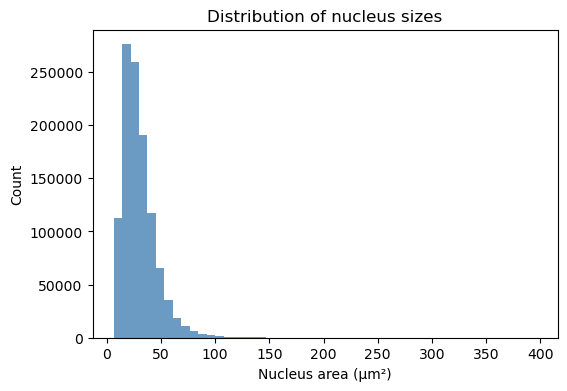

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to your cell TSV exported by QuPath
cells_tsv = r"C:\Users\Vivian\Documents\qupath_projects\cell_measurements\FA 57B.vsi - 20x_cells.tsv"

df = pd.read_csv(cells_tsv, sep="\t")
print(df.columns)
df.head()

plt.figure(figsize=(6,4))
plt.hist(df["Nucleus: Area"], bins=50, color="steelblue", alpha=0.8)
plt.xlabel("Nucleus area (µm²)")
plt.ylabel("Count")
plt.title("Distribution of nucleus sizes")
plt.show()


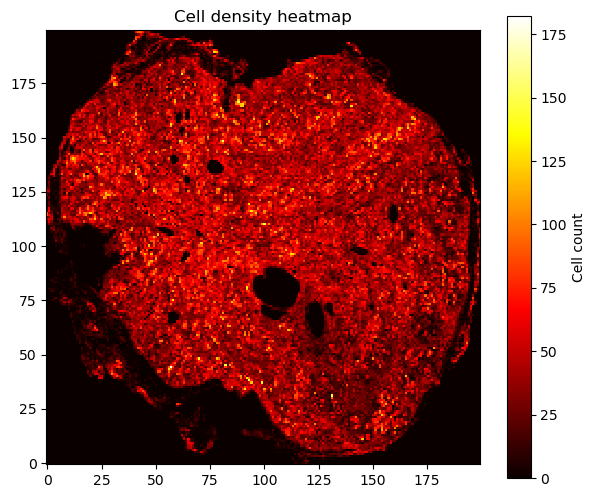

In [8]:
from scipy.stats import binned_statistic_2d

x = df["Centroid X µm"].values
y = df["Centroid Y µm"].values

# Choose binning for coarse density map
bins = 200  # increase for more detail

heatmap, xedges, yedges, _ = binned_statistic_2d(
    x, y, None, statistic="count", bins=bins
)

plt.figure(figsize=(7,6))
plt.imshow(
    heatmap.T, 
    origin="lower", 
    cmap="hot",
    interpolation="nearest"
)
plt.title("Cell density heatmap")
plt.colorbar(label="Cell count")
plt.show()


batch processing loading entire wsi

In [ ]:
import pandas as pd
from pathlib import Path
from paquo.projects import QuPathProject
import subprocess

# --------------------------------
# CONFIG
# --------------------------------

# Path where FA scans/, PT scans/ live
WSI_ROOT = Path(r"Z:\med-i_data\Data\Amoon\Pathology Raw")

# CSV listing only the slides you want
CSV_PATH = Path(r"C:\Users\Vivian\Documents\TRIDENT\wsi_10x2.csv")

QUPATH = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
PROJECT = r"C:\Users\Vivian\Documents\qupath_projects\project.qpproj"
GROOVY  = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\tile_and_detect_cells.groovy"

# --------------------------------
# 1. Load CSV
# --------------------------------
df = pd.read_csv(CSV_PATH)

# Must contain a column called "wsi"
assert "wsi" in df.columns

# Build full paths
slide_paths = [(WSI_ROOT / rel_path).resolve() for rel_path in df["wsi"]]

# Check existence
valid_slides = []
for p in slide_paths:
    if p.exists():
        valid_slides.append(p)
    else:
        print("WARNING: Slide not found:", p)

print(f"Found {len(valid_slides)} valid slides to process.")


# --------------------------------
# 2. Create QuPath project with only these slides
# --------------------------------
# with QuPathProject(PROJECT, mode="r+") as proj:
#     for slide in valid_slides:
#         print("Adding:", slide)
#         proj.add_image(str(slide))

# print("\nProject created:", PROJECT)

# Re-open the existing project WITHOUT deleting it
with QuPathProject(str(PROJECT), mode="r+") as proj:
    print("Slides already in project:")
    for entry in proj.images:
        print(" -", entry.image_name)

# --------------------------------
# 3. Run QuPath Groovy script over project
# --------------------------------
cmd = [
    QUPATH,
    "script",
    GROOVY,
    "--project", PROJECT
]

print("\nRunning batch cell detection…")
result = subprocess.run(cmd, capture_output=True, text=True)
print("Return code:", result.returncode)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)

print("\nDone! Check the project folder for cell_measurements/")


In [ ]:
import subprocess
from pathlib import Path

QUPATH = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
PROJECT = Path(r"C:\Users\Vivian\Documents\qupath_projects\project.qpproj")  # <— use the existing one
GROOVY  = Path(r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\tile_and_detect_cells.groovy")

cmd = [
    QUPATH,
    "script",
    str(GROOVY),
    "--project",
    str(PROJECT)
]

print("Running:", cmd)
result = subprocess.run(cmd, capture_output=True, text=True)
print("Return code:", result.returncode)
print("=== STDOUT ===")
print(result.stdout)
print("=== STDERR ===")
print(result.stderr)


Running: ['C:\\Users\\Vivian\\paquo_qupath\\QuPath-0.5.1\\QuPath-0.5.1 (console).exe', 'script', 'C:\\Users\\Vivian\\Documents\\qupath_ann_testing\\scripts\\tile_and_detect_cells.groovy', '--project', 'C:\\Users\\Vivian\\Documents\\qupath_projects\\project.qpproj']


In [ ]:
import subprocess
from pathlib import Path

QUPATH = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
PROJECT = r"C:\Users\Vivian\Documents\qupath_projects\project.qpproj"
GROOVY  = r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\tile_and_detect_cells_run2.groovy"

cmd = [QUPATH, "script", GROOVY, "--project", PROJECT]
subprocess.run(cmd, check=True)


In [ ]:
from paquo.projects import QuPathProject
from pathlib import Path

PROJECT = Path(r"C:\Users\Vivian\Documents\qupath_projects\project.qpproj")

with QuPathProject(str(PROJECT), mode="r") as proj:
    images = list(proj.images)

print(f"Project has {len(images)} images:")
for idx, entry in enumerate(images):
    print(idx, "->", entry.image_name)


In [ ]:
import subprocess
from pathlib import Path
from paquo.projects import QuPathProject

QUPATH = r"C:\Users\Vivian\paquo_qupath\QuPath-0.5.1\QuPath-0.5.1 (console).exe"
PROJECT = Path(r"C:\Users\Vivian\Documents\qupath_projects\project.qpproj")
GROOVY  = Path(r"C:\Users\Vivian\Documents\qupath_ann_testing\scripts\tile_and_detect_cells_run2.groovy")

# Get image list with names for logging
with QuPathProject(str(PROJECT), mode="r") as proj:
    images = list(proj.images)

for idx, entry in enumerate(images):
    print(f"\n=== Processing image {idx}: {entry.image_name} ===")

    cmd = [
        QUPATH,
        "script",
        str(GROOVY),
        "--project", str(PROJECT),
        "--image", str(idx),      # <--- key: process ONE image by index
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)

    print("Return code:", result.returncode)
    # Print just the tail of the logs so your notebook isn’t flooded
    print("---- STDOUT (tail) ----")
    print(result.stdout[-1000:])
    print("---- STDERR (tail) ----")
    print(result.stderr[-1000:])

    if result.returncode != 0:
        print(f"ERROR on image {idx} ({entry.image_name}), stopping loop.")
        break


In [5]:
import os
from pathlib import Path

import pandas as pd

# --- CONFIG ---
# Point this to your project dir; measurements are assumed under "cell_measurements"
PROJECT_DIR = Path(r"C:\Users\Vivian\Documents\qupath_projects")
MEAS_DIR = PROJECT_DIR / "cell_measurements"

print("Measurements dir:", MEAS_DIR)
if not MEAS_DIR.exists():
    raise FileNotFoundError(f"Measurements dir does not exist: {MEAS_DIR}")

# --- Collect all *_cells.tsv files ---
tsv_paths = sorted(MEAS_DIR.glob("*_cells.tsv"))
print(f"Found {len(tsv_paths)} TSV files")

if not tsv_paths:
    raise SystemExit("No measurement TSVs found – nothing to summarize.")

per_slide_stats = []

for tsv in tsv_paths:
    slide_name = tsv.name.replace("_cells.tsv", "")
    try:
        df = pd.read_csv(tsv, sep="\t")
    except Exception as e:
        print(f"WARNING: failed to read {tsv}: {e}")
        continue

    n_cells = len(df)

    # Try to pick some common QuPath column names; adjust if yours differ
    nucleus_area_col = None
    cell_area_col = None

    for col in df.columns:
        lower = col.lower()
        if nucleus_area_col is None and "nucleus" in lower and "area" in lower:
            nucleus_area_col = col
        if cell_area_col is None and "cell" in lower and "area" in lower:
            cell_area_col = col

    mean_nucleus_area = df[nucleus_area_col].mean() if nucleus_area_col else float("nan")
    mean_cell_area = df[cell_area_col].mean() if cell_area_col else float("nan")

    per_slide_stats.append({
        "slide": slide_name,
        "n_cells": n_cells,
        "mean_nucleus_area": mean_nucleus_area,
        "mean_cell_area": mean_cell_area,
    })

stats_df = pd.DataFrame(per_slide_stats)

# --- Global summary ---
total_cells = int(stats_df["n_cells"].sum())
total_slides = len(stats_df)

print("\n=== Global summary so far ===")
print(f"Slides with measurements: {total_slides}")
print(f"Total detected cells   : {total_cells}")
print(f"Cells per slide (mean) : {stats_df['n_cells'].mean():.1f}")
print(f"Cells per slide (median): {stats_df['n_cells'].median():.1f}")

# Optional: overall means of areas (only over slides where they exist)
if stats_df["mean_nucleus_area"].notna().any():
    print(f"Mean nucleus area (slide-mean across slides with data): "
          f"{stats_df['mean_nucleus_area'].dropna().mean():.2f}")
if stats_df["mean_cell_area"].notna().any():
    print(f"Mean cell area (slide-mean across slides with data): "
          f"{stats_df['mean_cell_area'].dropna().mean():.2f}")

# --- Top slides by cell count ---
print("\n=== Top 10 slides by #cells ===")
display_cols = ["slide", "n_cells", "mean_nucleus_area", "mean_cell_area"]
print(stats_df.sort_values("n_cells", ascending=False)[display_cols].head(10).to_string(index=False))

# If you want to inspect or save the full table:
# stats_df.to_csv(PROJECT_DIR / "cell_measurements_summary.csv", index=False)


Measurements dir: C:\Users\Vivian\Documents\qupath_projects\cell_measurements
Found 249 TSV files

=== Global summary so far ===
Slides with measurements: 249
Total detected cells   : 30438331
Cells per slide (mean) : 122242.3
Cells per slide (median): 90739.0
Mean nucleus area (slide-mean across slides with data): 25.01
Mean cell area (slide-mean across slides with data): 161.11

=== Top 10 slides by #cells ===
              slide  n_cells  mean_nucleus_area  mean_cell_area
  PT 36 B.vsi - 20x   662077          23.273920      144.523257
 PT 54 B2.vsi - 40x   649774          31.463982      179.545424
 PT 87 B2.vsi - 40x   639345          24.708912      133.045250
   FA 57B.vsi - 20x   551522          29.981173      146.110264
 PT 54 B1.vsi - 40x   445100          34.945329      184.036684
FA 129 B2.vsi - 40x   406181          29.601069      160.662094
 PT 51 B1.vsi - 40x   395271          28.454163      157.315934
 PT 71 B1.vsi - 40x   366389          30.819917      156.716529
 PT 53 B

In [4]:
import pandas as pd
from pathlib import Path

# --- CONFIG ---
PROJECT_DIR = Path(r"C:\Users\Vivian\Documents\qupath_projects")
MEAS_DIR = PROJECT_DIR / "cell_measurements"

print("Measurements dir:", MEAS_DIR)
tsv_paths = sorted(MEAS_DIR.glob("*_cells.tsv"))
print(f"Found {len(tsv_paths)} TSV files")

rows = []
for tsv in tsv_paths:
    slide = tsv.name.replace("_cells.tsv", "")

    # --- Determine FA or PT based on slide name ---
    lower = slide.lower()
    if "fa" in lower:
        cls = "FA"
    elif "pt" in lower:
        cls = "PT"
    else:
        cls = "Unknown"

    try:
        df = pd.read_csv(tsv, sep="\t")
    except Exception as e:
        print(f"WARNING: could not read {tsv}: {e}")
        continue

    n_cells = len(df)

    # Try to automatically find nucleus area & cell area columns
    nucleus_area_col = next((c for c in df.columns if "nucleus" in c.lower() and "area" in c.lower()), None)
    cell_area_col = next((c for c in df.columns if "cell" in c.lower() and "area" in c.lower()), None)

    mean_nucleus_area = df[nucleus_area_col].mean() if nucleus_area_col else float("nan")
    mean_cell_area = df[cell_area_col].mean() if cell_area_col else float("nan")

    rows.append({
        "slide": slide,
        "class": cls,
        "n_cells": n_cells,
        "mean_nucleus_area": mean_nucleus_area,
        "mean_cell_area": mean_cell_area,
    })

stats_df = pd.DataFrame(rows)

print("\n=== Summary table (head) ===")
print(stats_df.head())

# Filter only FA/PT valid cases
valid = stats_df[stats_df["class"].isin(["FA", "PT"])]

print("\nSlides included in FA/PT comparison:", len(valid))

# --- BASIC CLASS-WISE STATISTICS ---
summary = valid.groupby("class").agg({
    "n_cells": ["mean", "median", "sum"],
    "mean_nucleus_area": "mean",
    "mean_cell_area": "mean",
})

print("\n=== FA vs PT Summary ===")
print(summary)

# --- OPTIONAL: DETAIL STATS ---
fa = valid[valid["class"] == "FA"]
pt = valid[valid["class"] == "PT"]

print("\nFA slides:", len(fa), " | PT slides:", len(pt))

print("\nCells per slide:")
print("  FA mean:", fa["n_cells"].mean())
print("  PT mean:", pt["n_cells"].mean())

print("\nMean nucleus area per slide:")
print("  FA:", fa["mean_nucleus_area"].mean())
print("  PT:", pt["mean_nucleus_area"].mean())

print("\nMean cell area per slide:")
print("  FA:", fa["mean_cell_area"].mean())
print("  PT:", pt["mean_cell_area"].mean())

# --- OPTIONAL: STATISTICAL TESTS ---
from scipy.stats import mannwhitneyu

# Test total cells per slide
u_stat, p_value = mannwhitneyu(fa["n_cells"], pt["n_cells"], alternative="two-sided")
print("\nMann–Whitney U test (cells per slide):")
print("  U =", u_stat, "  p =", p_value)

# Nucleus area
if fa["mean_nucleus_area"].notna().any() and pt["mean_nucleus_area"].notna().any():
    u_stat, p_value = mannwhitneyu(
        fa["mean_nucleus_area"].dropna(),
        pt["mean_nucleus_area"].dropna(),
        alternative="two-sided"
    )
    print("\nMann–Whitney U test (mean nucleus area):")
    print("  U =", u_stat, "  p =", p_value)


Measurements dir: C:\Users\Vivian\Documents\qupath_projects\cell_measurements
Found 249 TSV files

=== Summary table (head) ===
                 slide class  n_cells  mean_nucleus_area  mean_cell_area
0  FA 100 B1.vsi - 40x    FA    67401          22.266528      156.382615
1  FA 100 B2.vsi - 40x    FA    80310          22.154988      153.944740
2  FA 101 B1.vsi - 40x    FA    79530          21.946965      152.075836
3  FA 101 B2.vsi - 40x    FA   186398          24.574080      157.428294
4  FA 102 B1.vsi - 40x    FA    70237          22.218459      160.715735

Slides included in FA/PT comparison: 249

=== FA vs PT Summary ===
             n_cells                     mean_nucleus_area mean_cell_area
                mean    median       sum              mean           mean
class                                                                    
FA     123848.693548  102603.0  15357238         24.797643     159.170034
PT     120648.744000   84272.0  15081093         25.225584     163.038

tsv analysis

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import mannwhitneyu

measure_dir = Path(r"C:\Users\Vivian\Documents\qupath_projects\cell_measurements")

# -------------------------------
# 1. List TSV files
# -------------------------------
tsvs = sorted(measure_dir.glob("*_cells.tsv"))
print("Found", len(tsvs), "TSV files")

# -------------------------------
# Helper: extract class from filename
# -------------------------------
def parse_class(name):
    n = name.lower()
    if "fa " in n:
        return "FA"
    if "pt " in n:
        return "PT"
    return "UNKNOWN"

# -------------------------------
# Helper: summarize one slide
# -------------------------------
def summarize_slide(tsv_path):
    df = pd.read_csv(tsv_path, sep="\t")
    slide_name = tsv_path.stem.replace("_cells", "")
    cls = parse_class(slide_name)

    # Identify morphometric columns
    morpho_cols = [c for c in df.columns if any(k in c.lower() for k in 
                     ["nucleus", "cell", "area", "perimeter", "circular"])]
    
    # Basic count
    summary = {
        "slide": slide_name,
        "class": cls,
        "n_cells": len(df)
    }

    # Compute robust statistics for each morpho column
    for c in morpho_cols:
        if pd.api.types.is_numeric_dtype(df[c]):
            summary[f"{c}__mean"] = df[c].mean()
            summary[f"{c}__median"] = df[c].median()
            summary[f"{c}__std"] = df[c].std()
            summary[f"{c}__p25"] = df[c].quantile(0.25)
            summary[f"{c}__p75"] = df[c].quantile(0.75)

    return summary

# -------------------------------
# 2. Build slide-level summary table
# -------------------------------
rows = []
for tsv in tsvs:
    rows.append(summarize_slide(tsv))

summary_df = pd.DataFrame(rows)
summary_df = summary_df[summary_df["class"].isin(["FA", "PT"])]
print("Slides included:", len(summary_df))

summary_df.head()


Found 249 TSV files
Slides included: 249


,slide,class,n_cells,Nucleus: Area__mean,Nucleus: Area__median,Nucleus: Area__std,Nucleus: Area__p25,Nucleus: Area__p75,Nucleus: Perimeter__mean,Nucleus: Perimeter__median,...,Cell: Eosin OD min__mean,Cell: Eosin OD min__median,Cell: Eosin OD min__std,Cell: Eosin OD min__p25,Cell: Eosin OD min__p75,Nucleus/Cell area ratio__mean,Nucleus/Cell area ratio__median,Nucleus/Cell area ratio__std,Nucleus/Cell area ratio__p25,Nucleus/Cell area ratio__p75
0,FA 100 B1.vsi - 40x,FA,67401,22.266528,18.9584,14.589824,15.2592,24.0448,19.696225,17.00230,...,0.043500,0.0406,0.029512,0.0323,0.0516,0.146047,0.1223,0.068807,0.1013,0.169300
1,FA 100 B2.vsi - 40x,FA,80310,22.154988,18.4960,15.179550,15.2592,24.0448,19.576638,16.78375,...,0.041234,0.0369,0.031267,0.0291,0.0489,0.148431,0.1219,0.072817,0.1004,0.174000
2,FA 101 B1.vsi - 40x,FA,79530,21.946965,18.4960,13.524550,14.3344,24.9696,19.597678,17.56800,...,0.045412,0.0435,0.031663,0.0334,0.0551,0.150832,0.1287,0.072536,0.0997,0.180800
3,FA 101 B2.vsi - 40x,FA,186398,24.574080,20.8080,14.991640,15.7216,29.1312,20.797495,18.96865,...,0.055024,0.0497,0.034949,0.0341,0.0708,0.162445,0.1422,0.074095,0.1100,0.193375
4,FA 102 B1.vsi - 40x,FA,70237,22.218459,19.8832,10.619945,15.7216,25.8944,19.236680,17.58740,...,-0.126988,0.0430,0.559367,0.0260,0.0655,0.142279,0.1271,0.056093,0.1046,0.162900


In [10]:
# Identify numeric morphometric columns
feature_cols = [c for c in summary_df.columns 
                if c not in ["slide", "class"] and summary_df[c].dtype != "object"]
results = []

for feat in feature_cols:
    vals_FA = summary_df[summary_df["class"]=="FA"][feat].dropna()
    vals_PT = summary_df[summary_df["class"]=="PT"][feat].dropna()
    
    if len(vals_FA)>5 and len(vals_PT)>5:
        U, p = mannwhitneyu(vals_FA, vals_PT, alternative="two-sided")
        diff = vals_PT.mean() - vals_FA.mean()  # positive → PT > FA
        
        results.append({
            "feature": feat,
            "FA_mean": vals_FA.mean(),
            "PT_mean": vals_PT.mean(),
            "difference_PT_minus_FA": diff,
            "U_stat": U,
            "p_value": p
        })

results_df = pd.DataFrame(results).sort_values("p_value")
results_df.head(20)


,feature,FA_mean,PT_mean,difference_PT_minus_FA,U_stat,p_value
115,Cell: Min caliper__p75,13.821892,13.987636,0.165744,5386.0,0.000032
92,Cell: Area__median,159.748013,163.965190,4.217177,5809.5,0.000639
111,Cell: Min caliper__mean,12.120942,12.320953,0.200011,5861.0,0.000890
112,Cell: Min caliper__median,12.552358,12.766714,0.214355,5892.5,0.001080
97,Cell: Perimeter__median,46.639944,47.088862,0.448918,5961.5,0.001653
83,Nucleus: Eosin OD min__std,0.161621,0.234865,0.073245,5997.0,0.002042
158,Cell: Eosin OD min__std,0.146936,0.220428,0.073492,6002.0,0.002104
91,Cell: Area__mean,159.170034,163.038951,3.868916,6056.0,0.002881
109,Cell: Max caliper__p25,14.816633,14.972577,0.155943,6079.0,0.003285
99,Cell: Perimeter__p25,41.712320,42.387986,0.675666,6119.0,0.004114


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# summary_df is your DataFrame from earlier
df = summary_df.copy()

# Drop non-feature columns
X = df.drop(columns=["slide", "class"])

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Target
y = df["class"].map({"FA":0, "PT":1})   # Binary encoding


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


patient level split

In [18]:
import re

def extract_patient(slide_name):
    # Matches like "FA 100", "PT 38", "FA 57"
    m = re.match(r"(FA|PT)\s*\d+", slide_name)
    return m.group(0) if m else slide_name

summary_df["patient_id"] = summary_df["slide"].apply(extract_patient)


In [19]:
from sklearn.model_selection import train_test_split

patients = summary_df["patient_id"].unique()

train_patients, test_patients = train_test_split(
    patients, test_size=0.25, random_state=42, stratify=[p.split()[0] for p in patients]
)

train_df = summary_df[summary_df["patient_id"].isin(train_patients)]
test_df  = summary_df[summary_df["patient_id"].isin(test_patients)]


In [20]:
X_train = train_df.drop(columns=["slide","class","patient_id"]).select_dtypes(include='number')
y_train = train_df["class"].map({"FA": 0, "PT": 1})

X_test  = test_df.drop(columns=["slide","class","patient_id"]).select_dtypes(include='number')
y_test  = test_df["class"].map({"FA": 0, "PT": 1})


In [22]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = summary_df.copy()
df = df[df["class"].isin(["FA", "PT"])].reset_index(drop=True)

def extract_patient(slide_name):
    # e.g. "FA 100 B1.vsi - 40x" -> "FA 100"
    m = re.match(r"(FA|PT)\s*\d+", slide_name)
    return m.group(0) if m else slide_name

df["patient_id"] = df["slide"].apply(extract_patient)

print("Total slides:", len(df))
print("Unique patients:", df["patient_id"].nunique())


Total slides: 249
Unique patients: 145


In [23]:
patients = df["patient_id"].unique()

# Stratify by lesion type at patient level (FA vs PT)
patient_classes = []
for pid in patients:
    # majority label for that patient
    cls = df[df["patient_id"] == pid]["class"].mode()[0]
    patient_classes.append(cls)

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.25,
    random_state=42,
    stratify=patient_classes
)

train_df = df[df["patient_id"].isin(train_patients)].reset_index(drop=True)
test_df  = df[df["patient_id"].isin(test_patients)].reset_index(drop=True)

print("Train slides:", len(train_df), "Test slides:", len(test_df))


Train slides: 184 Test slides: 65


In [24]:
# Choose numeric feature columns only, and drop ID columns
feature_cols = [
    c for c in df.columns
    if c not in ["slide", "class", "patient_id"] and np.issubdtype(df[c].dtype, np.number)
]

X_train = train_df[feature_cols].copy()
y_train = train_df["class"].map({"FA": 0, "PT": 1}).copy()

X_test  = test_df[feature_cols].copy()
y_test  = test_df["class"].map({"FA": 0, "PT": 1}).copy()

print("Shapes before NaN filtering:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)


Shapes before NaN filtering:
X_train: (184, 166) y_train: (184,)
X_test : (65, 166) y_test : (65,)


In [25]:
# Drop rows with any NaN in X, and apply same mask to y
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

print("Shapes after NaN filtering:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)


Shapes after NaN filtering:
X_train: (184, 166) y_train: (184,)
X_test : (65, 166) y_test : (65,)


In [29]:
import pandas as pd
import numpy as np
from scipy.spatial import ConvexHull

def estimate_tissue_area_mm2(df):
    # nuclei centroid columns
    xs = df["Nucleus: Centroid X µm"]
    ys = df["Nucleus: Centroid Y µm"]

    points = np.vstack([xs, ys]).T

    hull = ConvexHull(points)
    area_um2 = hull.area  # Actually returns perimeter, so:
    area_um2 = hull.volume  # For 2D hull, volume = area

    area_mm2 = area_um2 / 1e6
    return area_mm2


In [34]:
from pathlib import Path
UNI_DIR     = Path(r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_10x\uniextracted_mag10x_patch224_fp\feats_pt") 

all_pt_files = list(UNI_DIR.rglob("*.pt"))
print("Found", len(all_pt_files), ".pt files")

for p in all_pt_files[:10]:
    print("  ", p.name)


Found 240 .pt files
   FA 100 B1.pt
   FA 100 B2.pt
   FA 101 B1.pt
   FA 101 B2.pt
   FA 102 B1.pt
   FA 102 B2.pt
   FA 103 B1.pt
   FA 103 B2.pt
   FA 104 B1.pt
   FA 104 B2.pt


In [46]:
import re
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------------------
# 0. Start from your morphometric summary
# ----------------------------------------
df = summary_df.copy()
df = df[df["class"].isin(["FA", "PT"])].reset_index(drop=True)

def extract_patient(slide_name: str) -> str:
    # "FA 100 B1.vsi - 40x" -> "FA 100"
    m = re.match(r"(FA|PT)\s*\d+", slide_name)
    return m.group(0) if m else slide_name

def make_slide_key_from_morpho(slide_name: str) -> str:
    """
    Example:
      "FA 100 B1.vsi - 40x" -> "fa_100_b1"
    """
    # drop mag part & .vsi
    base = slide_name.split(".vsi")[0]      # "FA 100 B1"
    base = base.split("-")[0].strip()      # still "FA 100 B1"
    base = re.sub(r"\s+", "_", base)       # "FA_100_B1"
    return base.lower()                    # "fa_100_b1"

df["patient_id"] = df["slide"].apply(extract_patient)
df["slide_key"]  = df["slide"].apply(make_slide_key_from_morpho)

print("Example morpho rows:")
print(df[["slide", "class", "patient_id", "slide_key"]].head())

# ----------------------------------------
# 1. Load UNI deep features
# ----------------------------------------
# UNI_DIR     = Path(r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_10x\uniextracted_mag10x_patch224_fp\feats_pt") # 10x
UNI_DIR = Path(r"C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\uniextracted_mag25x_patch224_fp\feats_pt") # multi-scale (2.5 5)
# UNI_DIR = Path(r"C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_2.5x\uniextracted_mag2x_patch224_fp\feats_pt") # 2.5x
# UNI_DIR = Path(r'C:\Users\Vivian\Documents\PANTHER\PANTHER\features\multiscale\uniextracted_mag210x_patch224_fp\feats_pt') # multi-scale (2.5 10)
# UNI_DIR = Path(r'C:\Users\Vivian\Documents\PANTHER\PANTHER\features\uniextracted_mag5x_patch224_fp\feats_pt') # 5x

def make_slide_key_from_uni_filename(fname: str) -> str:
    """
    For UNI filenames like:
      "FA 100 B1.pt" -> "fa_100_b1"
    """
    stem = Path(fname).stem        # "FA 100 B1"
    stem = stem.strip().lower()    # "fa 100 b1"
    stem = re.sub(r"\s+", "_", stem)  # "fa_100_b1"
    return stem

deep_feats_dict = {}

all_pt_files = list(UNI_DIR.glob("*.pt"))
print("Found", len(all_pt_files), ".pt files in UNI_DIR:")
for p in all_pt_files[:10]:
    print("  ", p.name)

for pt_path in all_pt_files:
    key = make_slide_key_from_uni_filename(pt_path.name)
    tensor = torch.load(pt_path, map_location="cpu")

    # ensure 1D vector per slide
    arr = tensor.numpy() if isinstance(tensor, torch.Tensor) else np.array(tensor)
    if arr.ndim == 2:
        arr = arr.mean(axis=0)
    elif arr.ndim > 2:
        arr = arr.reshape(arr.shape[0], -1).mean(axis=0)

    deep_feats_dict[key] = arr

print("Number of UNI slide keys:", len(deep_feats_dict))

# ----------------------------------------
# 2. Align morpho + deep by common slide_key
# ----------------------------------------
morpho_keys = set(df["slide_key"])
uni_keys    = set(deep_feats_dict.keys())
common_keys = morpho_keys & uni_keys

print("Morpho slide keys:", len(morpho_keys))
print("UNI slide keys   :", len(uni_keys))
print("Common keys      :", len(common_keys))

if len(common_keys) == 0:
    # helpful debug if it still fails
    print("Sample morpho keys:", list(morpho_keys)[:10])
    print("Sample UNI keys   :", list(uni_keys)[:10])
    raise RuntimeError("No overlap between morpho slide_key and UNI .pt keys – adjust key functions.")

# keep only slides with both morpho + deep
df_fused = df[df["slide_key"].isin(common_keys)].reset_index(drop=True)
print("Slides with both morpho + deep:", len(df_fused))

# build deep feature matrix aligned to df_fused
deep_feat_list = []
for key in df_fused["slide_key"]:
    deep_feat_list.append(deep_feats_dict[key])

deep_feat_matrix = np.vstack(deep_feat_list)
print("deep_feat_matrix shape:", deep_feat_matrix.shape)


# -------------------------------------------------------------------
# 4. Build morphometric feature matrix
# -------------------------------------------------------------------
# numeric morphometric feature columns
exclude_cols = ["slide", "class", "patient_id", "slide_key", "has_deep"]
morpho_cols = [
    c for c in df_fused.columns
    if c not in exclude_cols and np.issubdtype(df_fused[c].dtype, np.number)
]

X_morpho = df_fused[morpho_cols].copy()
y        = df_fused["class"].map({"FA": 0, "PT": 1}).values

print("Morpho feat matrix shape:", X_morpho.shape)
print("Number of labels:", len(y))

# Handle NaNs (drop rows with NaNs in morpho)
mask_nonan = X_morpho.notna().all(axis=1)
X_morpho = X_morpho[mask_nonan].reset_index(drop=True)
deep_feat_matrix = deep_feat_matrix[mask_nonan]
df_fused = df_fused[mask_nonan].reset_index(drop=True)
y = y[mask_nonan]

print("After NaN filtering: morpho:", X_morpho.shape, "deep:", deep_feat_matrix.shape, "labels:", len(y))

# -------------------------------------------------------------------
# 5. Fuse: [deep | morpho]
# -------------------------------------------------------------------
X_fused = np.hstack([deep_feat_matrix, X_morpho.values])
print("Fused feature matrix shape:", X_fused.shape)

# -------------------------------------------------------------------
# 6. Patient-level train/test split
# -------------------------------------------------------------------
patients = df_fused["patient_id"].unique()

# Build a patient-level class label (majority class for each patient)
patient_classes = []
for pid in patients:
    cls = df_fused[df_fused["patient_id"] == pid]["class"].mode()[0]
    patient_classes.append(cls)

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.25,
    random_state=42,
    stratify=patient_classes
)

train_mask = df_fused["patient_id"].isin(train_patients)
test_mask  = df_fused["patient_id"].isin(test_patients)

X_train = X_fused[train_mask.values]
X_test  = X_fused[test_mask.values]
y_train = y[train_mask.values]
y_test  = y[test_mask.values]

print("Train slides:", X_train.shape[0], "Test slides:", X_test.shape[0])

# -------------------------------------------------------------------
# 7. Train classifiers on fused features
# -------------------------------------------------------------------

# 7a. Logistic Regression (with scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression (FUSED) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("AUC     :", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

# 7b. Random Forest (no scaling needed)
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest (FUSED) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC     :", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))


Example morpho rows:
                 slide class patient_id  slide_key
0  FA 100 B1.vsi - 40x    FA     FA 100  fa_100_b1
1  FA 100 B2.vsi - 40x    FA     FA 100  fa_100_b2
2  FA 101 B1.vsi - 40x    FA     FA 101  fa_101_b1
3  FA 101 B2.vsi - 40x    FA     FA 101  fa_101_b2
4  FA 102 B1.vsi - 40x    FA     FA 102  fa_102_b1
Found 240 .pt files in UNI_DIR:
   FA 100 B1.pt
   FA 100 B2.pt
   FA 101 B1.pt
   FA 101 B2.pt
   FA 102 B1.pt
   FA 102 B2.pt
   FA 103 B1.pt
   FA 103 B2.pt
   FA 104 B1.pt
   FA 104 B2.pt
Number of UNI slide keys: 240
Morpho slide keys: 240
UNI slide keys   : 240
Common keys      : 240
Slides with both morpho + deep: 249
deep_feat_matrix shape: (249, 2048)
Morpho feat matrix shape: (249, 166)
Number of labels: 249
After NaN filtering: morpho: (249, 166) deep: (249, 2048) labels: 249
Fused feature matrix shape: (249, 2214)
Train slides: 184 Test slides: 65

=== Logistic Regression (FUSED) ===
Accuracy: 0.7846153846153846
AUC     : 0.8068181818181819
            

In [47]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# ----------------------------------------------
# 1. Prepare labels & patient groups
# ----------------------------------------------
y = df_fused["class"].map({"FA":0, "PT":1}).values
groups = df_fused["patient_id"].values

# Deep features only:
X_deep = deep_feat_matrix   # shape (N, D)

# ----------------------------------------------
# 2. Patient-level train/test split
# ----------------------------------------------
gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X_deep, y, groups))

X_train, X_test = X_deep[train_idx], X_deep[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ----------------------------------------------
# 3. Logistic Regression baseline
# ----------------------------------------------
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
proba_lr = lr.predict_proba(X_test)[:,1]

print("\n=== DEEP ONLY — Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("AUC     :", roc_auc_score(y_test, proba_lr))
print(classification_report(y_test, pred_lr))

# ----------------------------------------------
# 4. Random Forest baseline
# ----------------------------------------------
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:,1]

print("\n=== DEEP ONLY — Random Forest ===")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("AUC     :", roc_auc_score(y_test, proba_rf))
print(classification_report(y_test, pred_rf))



=== DEEP ONLY — Logistic Regression ===
Accuracy: 0.7222222222222222
AUC     : 0.7972136222910217
              precision    recall  f1-score   support

           0       0.68      0.76      0.72        34
           1       0.76      0.68      0.72        38

    accuracy                           0.72        72
   macro avg       0.72      0.72      0.72        72
weighted avg       0.73      0.72      0.72        72


=== DEEP ONLY — Random Forest ===
Accuracy: 0.7083333333333334
AUC     : 0.766640866873065
              precision    recall  f1-score   support

           0       0.68      0.74      0.70        34
           1       0.74      0.68      0.71        38

    accuracy                           0.71        72
   macro avg       0.71      0.71      0.71        72
weighted avg       0.71      0.71      0.71        72



In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_feats = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x=top_feats.values, y=top_feats.index)
plt.title("Top 20 Feature Importances (RF)")
plt.tight_layout()
plt.show()


                Feature Set Model  Accuracy    AUC  PT Recall
0               Morpho Only     -     0.620  0.710       0.66
1               Morpho Only    RF     0.760  0.780       0.72
2                 Deep 2.5×    LR     0.710  0.795       0.68
3                 Deep 2.5×    RF     0.736  0.755       0.71
4                   Deep 5×    LR     0.722  0.802       0.68
5                   Deep 5×    RF     0.667  0.770       0.68
6             Deep 2.5×+10×    LR     0.722  0.797       0.68
7             Deep 2.5×+10×    RF     0.708  0.767       0.68
8       Fused 2.5× + Morpho    LR     0.692  0.795       0.79
9       Fused 2.5× + Morpho    RF     0.708  0.796       0.67
10        Fused 5× + Morpho    LR     0.738  0.763       0.76
11        Fused 5× + Morpho    RF     0.723  0.815       0.61
12  Fused 2.5×+10× + Morpho    LR     0.785  0.807       0.82
13  Fused 2.5×+10× + Morpho    RF     0.754  0.817       0.73
14   Fused 2.5×+5× + Morpho    LR     0.785  0.807       0.82
15   Fus

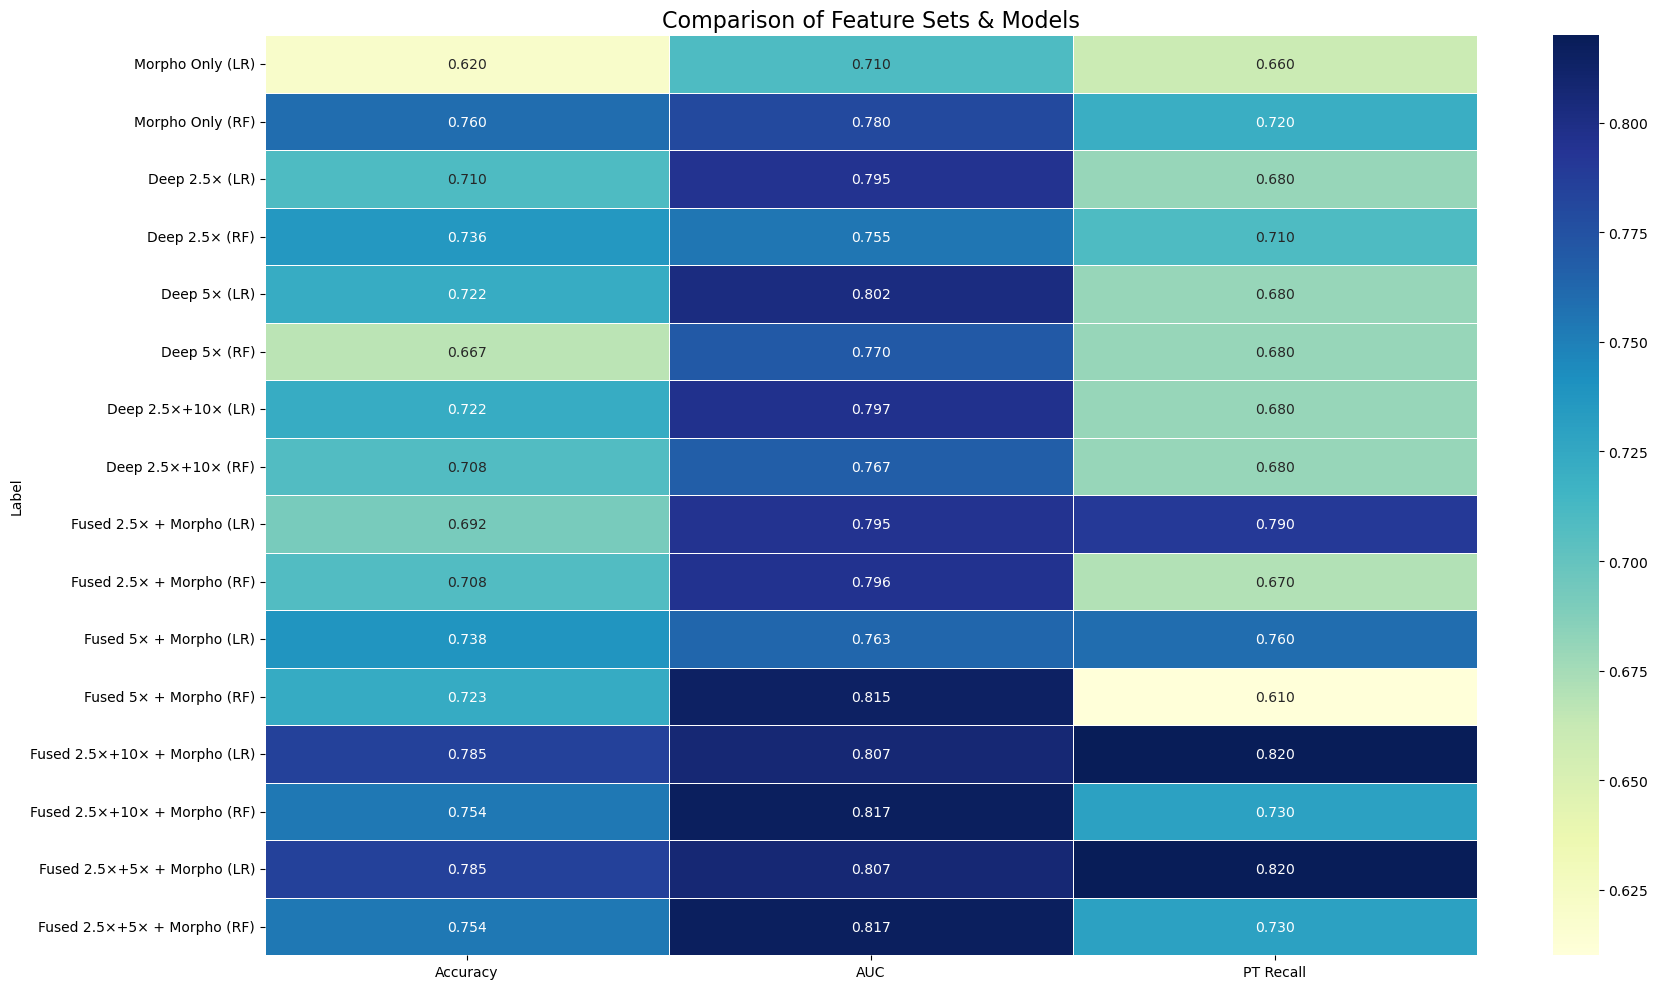

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------
# 1. Build summary table as a DataFrame
# --------------------------------------
data = [
    ["Morpho Only", "-", 0.62, 0.71, 0.66],
    ["Morpho Only", "RF", 0.76, 0.78, 0.72],

    ["Deep 2.5×", "LR", 0.71, 0.795, 0.68],
    ["Deep 2.5×", "RF", 0.736, 0.755, 0.71],

    ["Deep 5×", "LR", 0.722, 0.802, 0.68],
    ["Deep 5×", "RF", 0.667, 0.770, 0.68],

    ["Deep 2.5×+10×", "LR", 0.722, 0.797, 0.68],
    ["Deep 2.5×+10×", "RF", 0.708, 0.767, 0.68],

    ["Fused 2.5× + Morpho", "LR", 0.692, 0.795, 0.79],
    ["Fused 2.5× + Morpho", "RF", 0.708, 0.796, 0.67],

    ["Fused 5× + Morpho", "LR", 0.738, 0.763, 0.76],
    ["Fused 5× + Morpho", "RF", 0.723, 0.815, 0.61],

    ["Fused 2.5×+10× + Morpho", "LR", 0.785, 0.807, 0.82],
    ["Fused 2.5×+10× + Morpho", "RF", 0.754, 0.817, 0.73],

    ["Fused 2.5×+5× + Morpho", "LR", 0.785, 0.807, 0.82],
    ["Fused 2.5×+5× + Morpho", "RF", 0.754, 0.817, 0.73],
]

df = pd.DataFrame(data, columns=["Feature Set", "Model", "Accuracy", "AUC", "PT Recall"])
print(df)

# --------------------------------------
# 2. Create a heatmap-like table plot
# --------------------------------------
plt.figure(figsize=(18, 10))

# Convert to pivot-like format for visualization
plot_df = df.copy()
plot_df["Model"] = plot_df["Model"].replace("-", "LR")

# Prepare index for labeling
plot_df["Label"] = plot_df["Feature Set"] + " (" + plot_df["Model"] + ")"
plot_df = plot_df.set_index("Label")[["Accuracy", "AUC", "PT Recall"]]

# Draw heatmap
sns.heatmap(
    plot_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f",
    linewidths=.5,
    cbar=True
)

plt.title("Comparison of Feature Sets & Models", fontsize=16)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

# Optional: Save figure
# plt.savefig("model_comparison_table.png", dpi=300)


fix geojson

In [6]:
import json
from pathlib import Path

gj_path = Path(r"C:\Users\Vivian\Documents\qupath_projects\cellmeas\PT 52 B.vsi - 20x_nuclei.geojson")

with gj_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

changed = False

for feat in data.get("features", []):
    geom = feat.get("geometry", {})
    if geom.get("type") != "Polygon":
        continue
    coords = geom.get("coordinates", [])
    if not coords:
        continue

    ring = coords[0]
    if len(ring) < 3:
        continue

    first = ring[0]
    last = ring[-1]

    # Close the ring if needed
    if first != last:
        ring.append(first)
        changed = True

if changed:
    with gj_path.open("w", encoding="utf-8") as f:
        json.dump(data, f)
    print("Fixed:", gj_path)
else:
    print("Already OK:", gj_path)


Fixed: C:\Users\Vivian\Documents\qupath_projects\cellmeas\PT 52 B.vsi - 20x_nuclei.geojson
